# Exploratory data analysis

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# Configuration to download file
full_path = "../data/raw/downloaded_data.csv"

def download_from_gcs(project_id, bucket_name, source_blob_name, destination_file_path):
    """Downloads a file from Google Cloud Storage."""
    client = storage.Client(project=project_id)
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(source_blob_name)

    blob.download_to_filename(destination_file_path)
    print(f"File gs://{bucket_name}/{source_blob_name} downloaded to {destination_file_path}")

# Usage
download_from_gcs(
    project_id="ai-dj-487610",
    bucket_name="ai-dj-487610-bucket",
    source_blob_name="data/uploaded_file.csv",
    destination_file_path=full_path
)

File gs://ai-dj-487610-bucket/data/uploaded_file.csv downloaded to ../data/raw/downloaded_data.csv


In [6]:
df = pd.read_csv(full_path)
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

## Dataset overview

In [7]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [15]:
df.describe(include='all')

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,114000.000000,114000,113999,113999,113999,114000.000000,1.140000e+05,114000,114000.000000,114000.000000,...,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000
unique,NaN,89741,31437,46589,73608,NaN,NaN,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,NaN,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,NaN,9,279,195,151,NaN,NaN,104253,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,56999.500000,NaN,NaN,NaN,NaN,33.238535,2.280292e+05,NaN,0.566800,0.641383,...,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,NaN
std,32909.109681,NaN,NaN,NaN,NaN,22.305078,1.072977e+05,NaN,0.173542,0.251529,...,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,0.000000,0.000000,...,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,28499.750000,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,...,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,NaN
50%,56999.500000,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,...,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,85499.250000,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,...,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


In [10]:
df.nunique()

Unnamed: 0          114000
track_id             89741
artists              31437
album_name           46589
track_name           73608
popularity             101
duration_ms          50697
explicit                 2
danceability          1174
energy                2083
key                     12
loudness             19480
mode                     2
speechiness           1489
acousticness          5061
instrumentalness      5346
liveness              1722
valence               1790
tempo                45653
time_signature           5
track_genre            114
dtype: int64

In [11]:
df[df.isna().any(axis=1)]
# Since there is only 1 observations where artists, album_name and track_name are missing, and the number of observations is huge
# with respect to the number of missing values, we can consistently delete this observation.

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [12]:
df = df.dropna()
df[df.isna().any(axis=1)]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


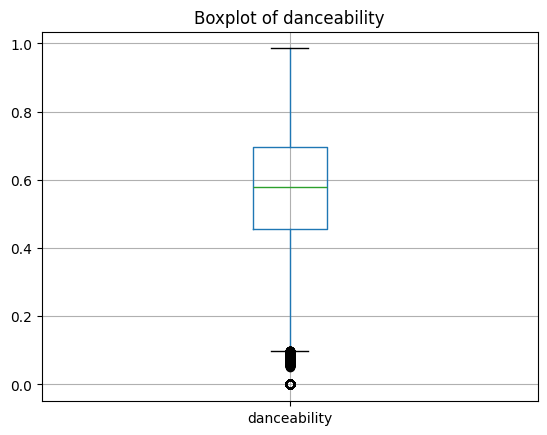

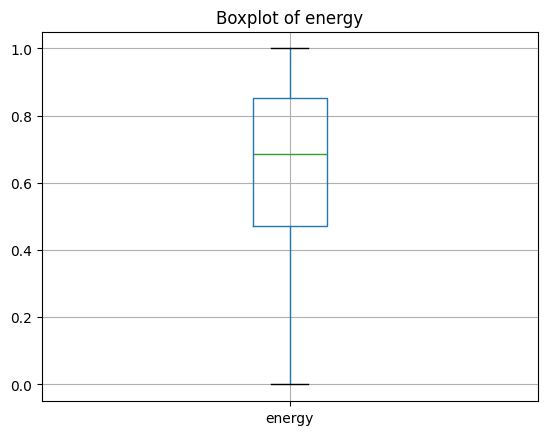

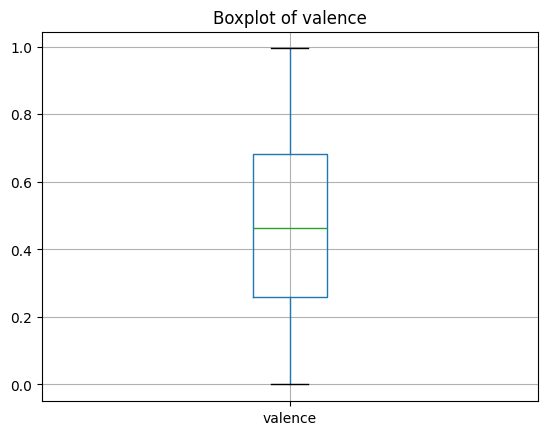

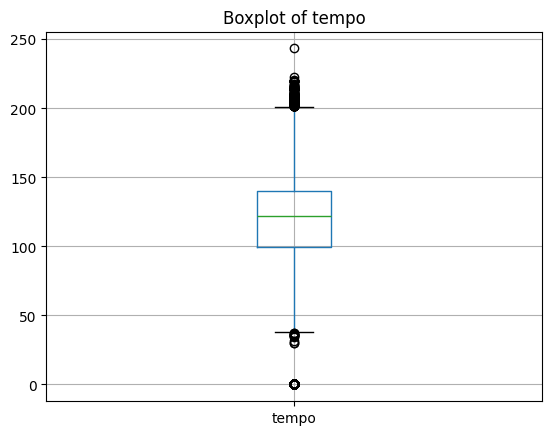

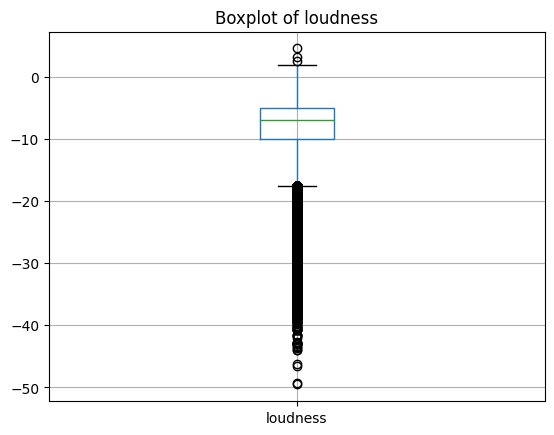

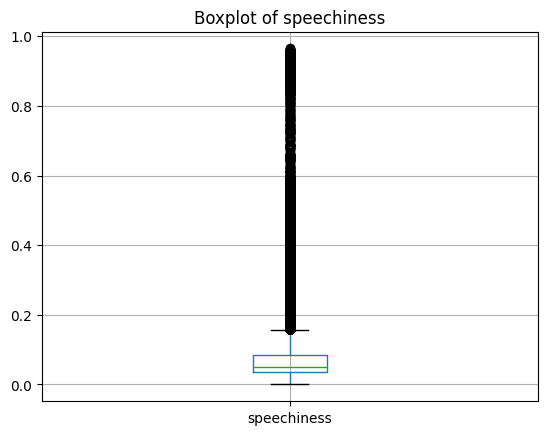

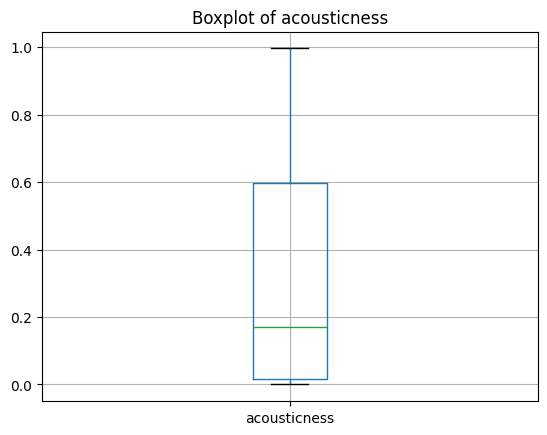

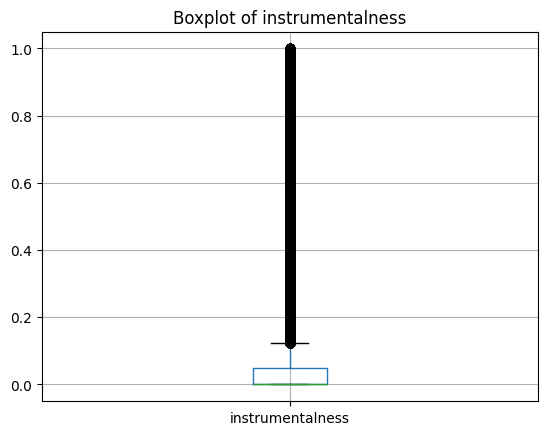

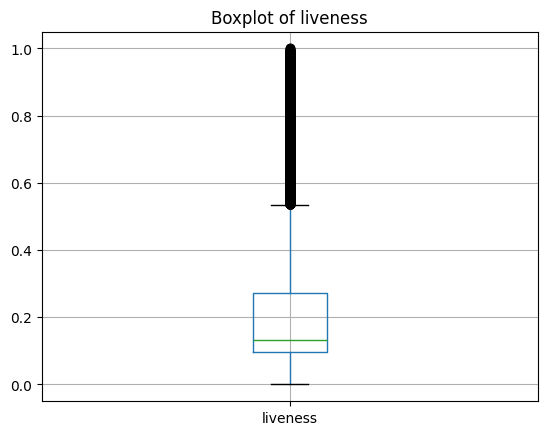

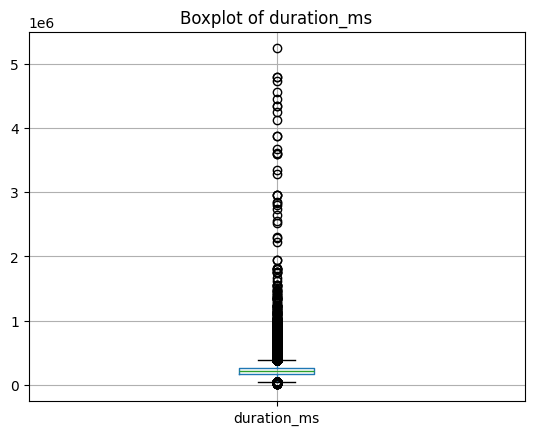

In [88]:
for i in ['danceability','energy','valence','tempo','loudness','speechiness','acousticness',
                'instrumentalness','liveness','duration_ms']:
    df.boxplot(column=i)
    plt.title("Boxplot of "+i)
    plt.show()

## Correlation analysis

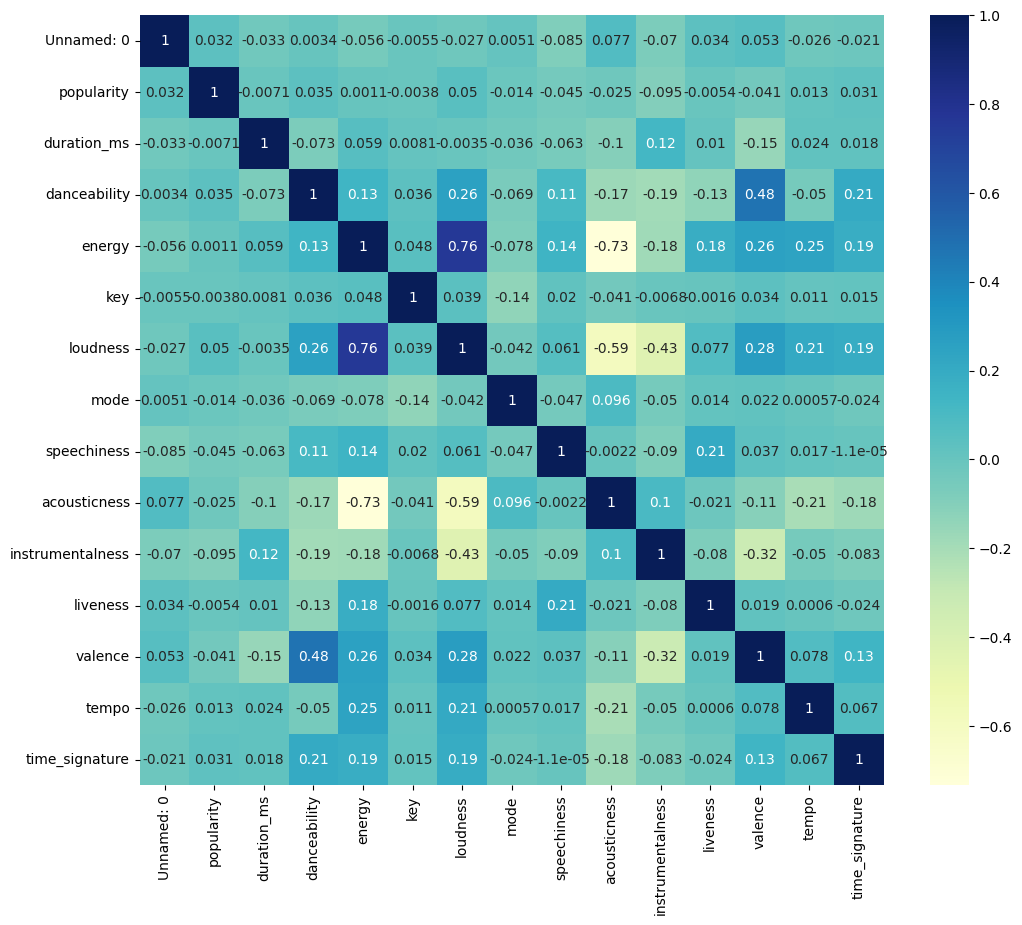

In [89]:
datacorr = df.select_dtypes(include='number')
plt.figure(figsize=(12,10))
sns.heatmap(datacorr.corr(), cmap="YlGnBu", annot=True)
plt.show()

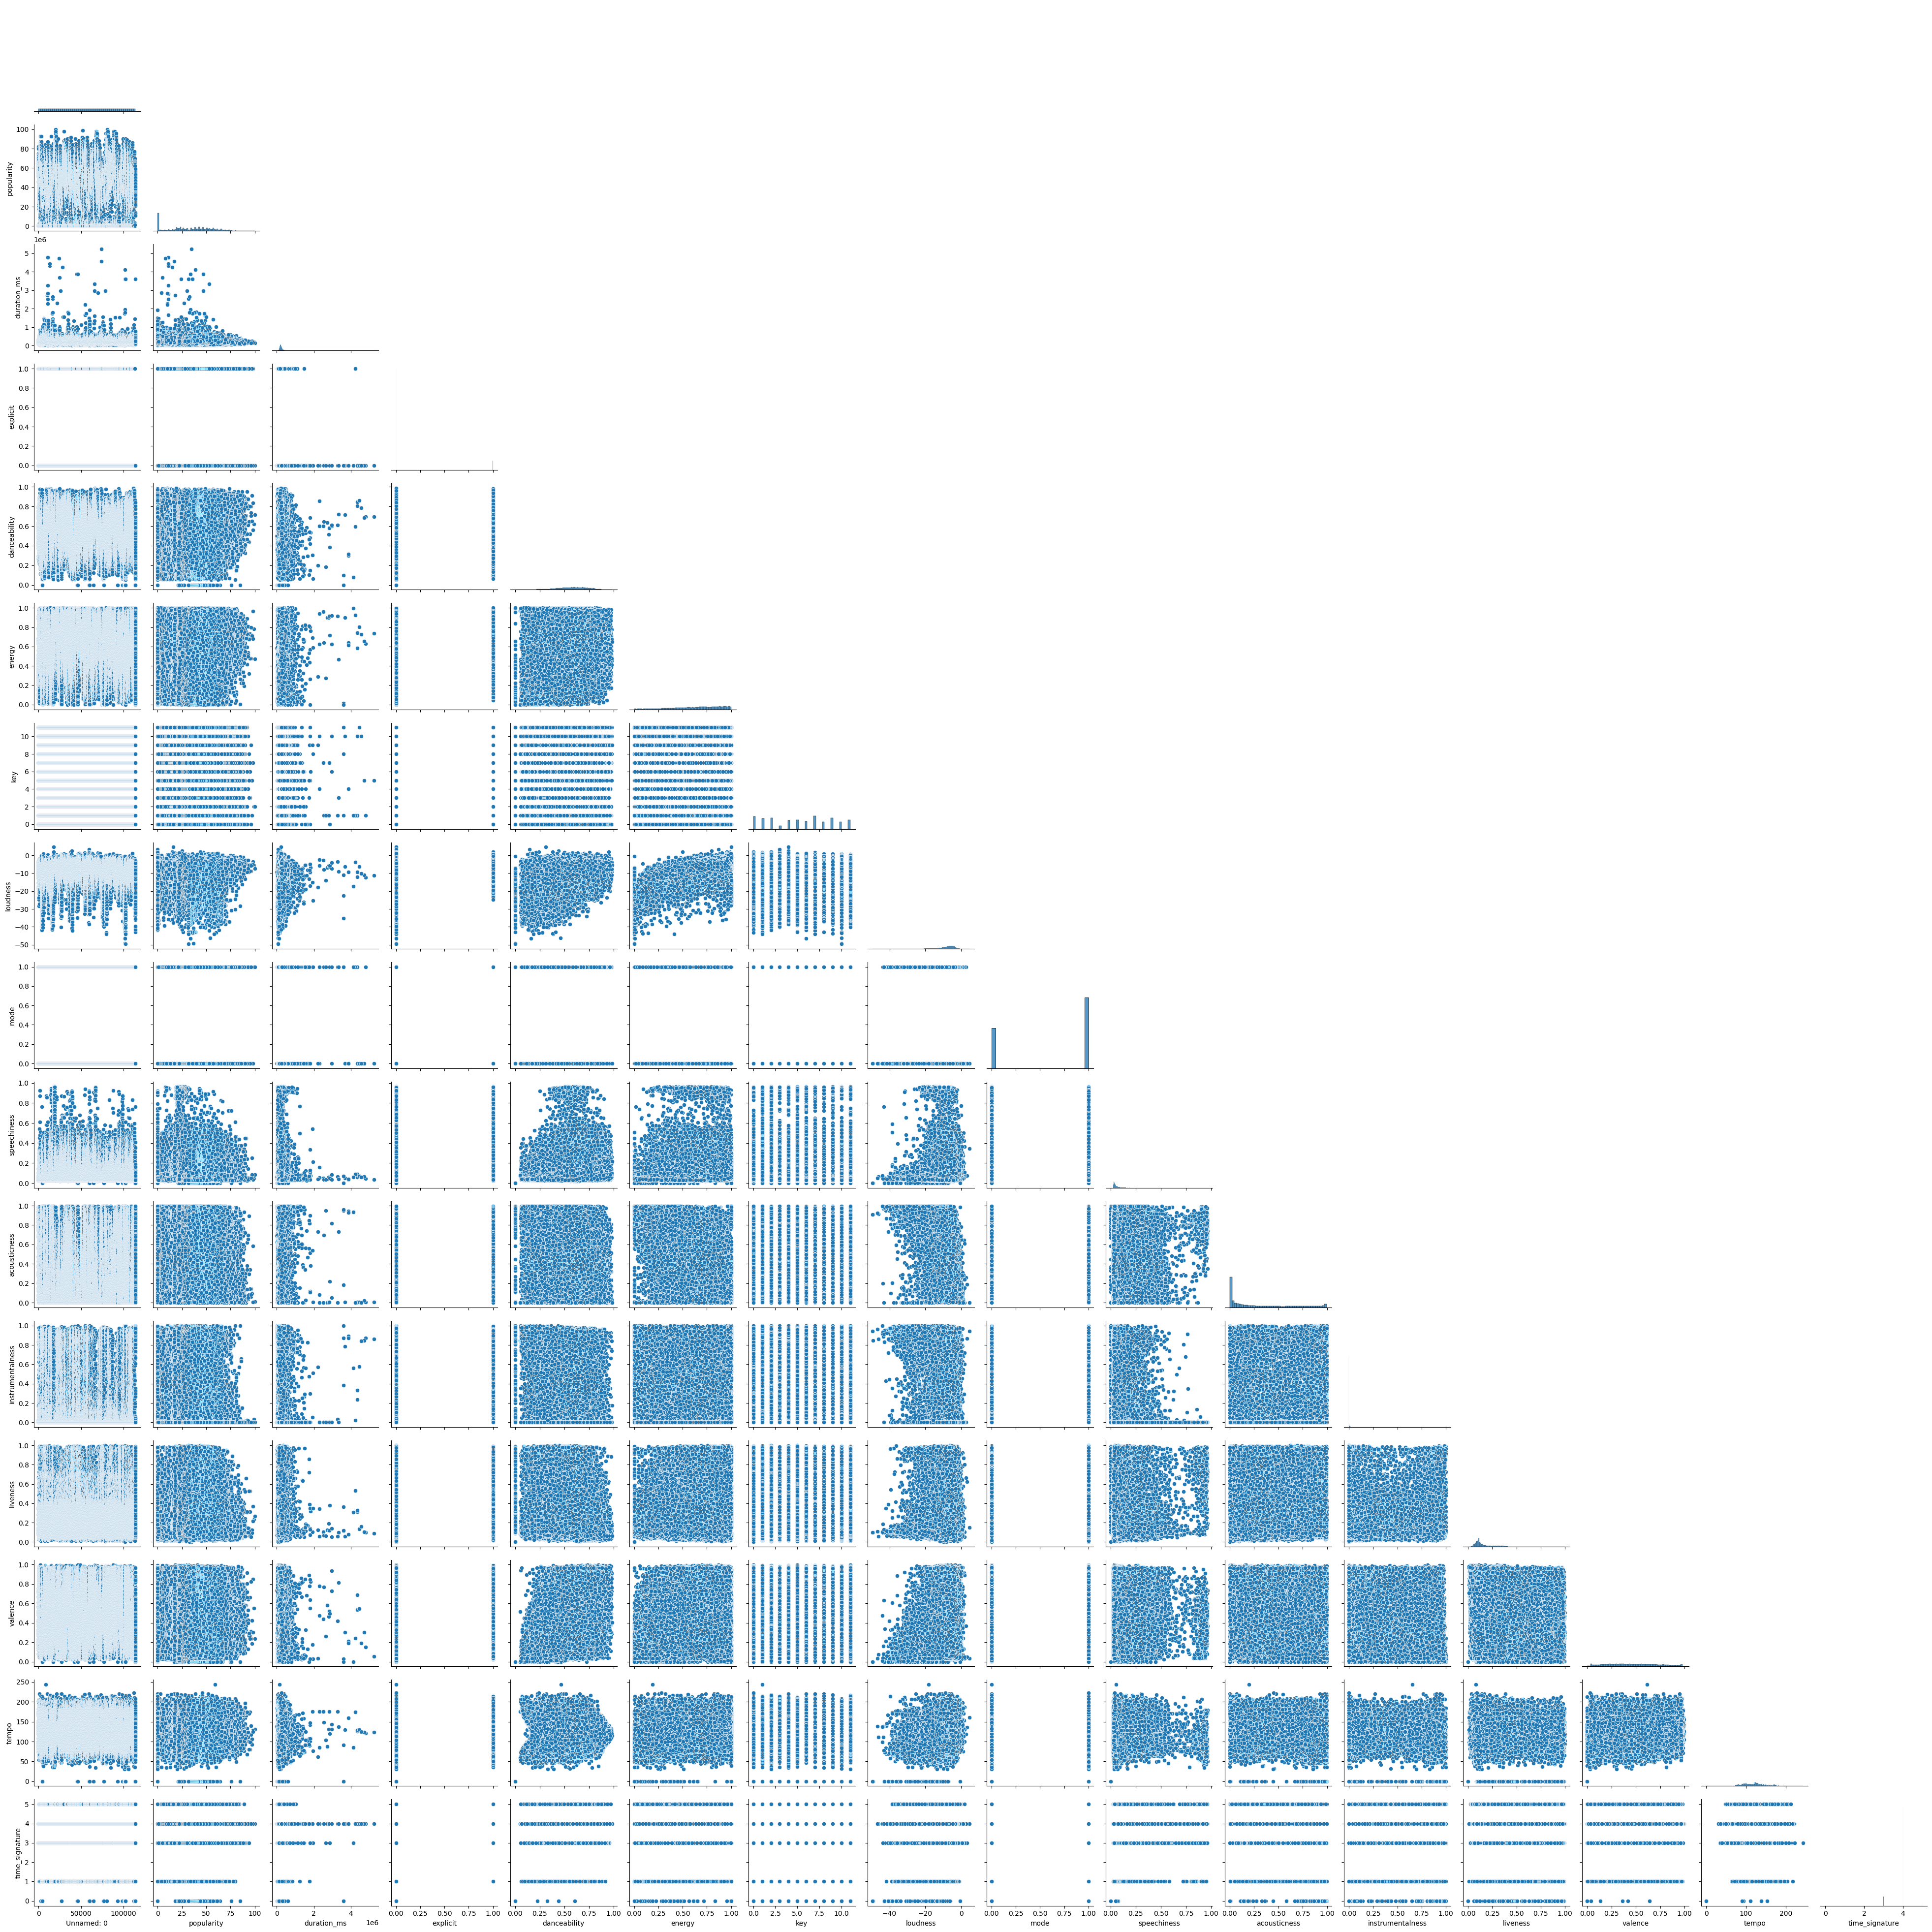

In [ ]:
sns.pairplot(df, kind='scatter', corner=True)

## PCA

Text(0.5, 0, 'PCA3')

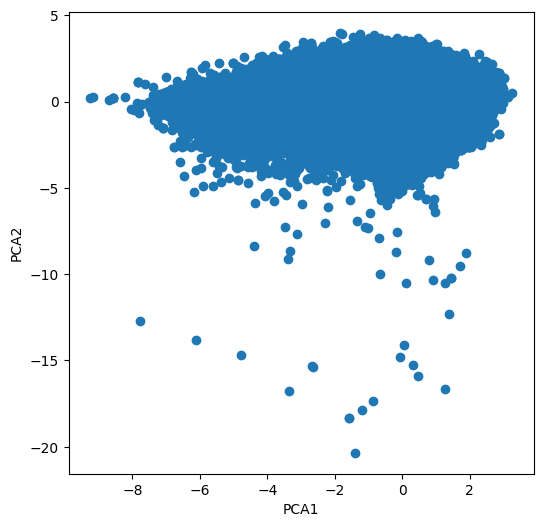

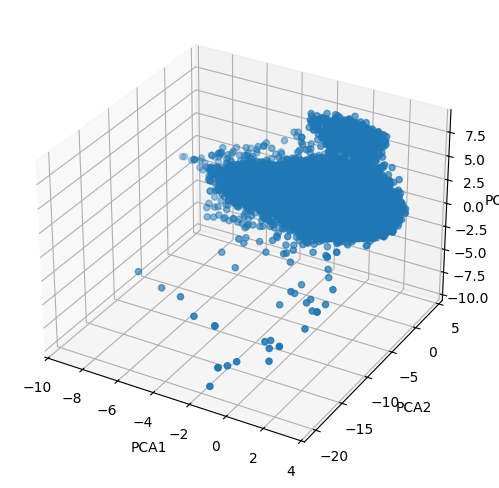

In [ ]:
selectionPCA = ['danceability','energy','valence','tempo','loudness','speechiness','acousticness',
                'instrumentalness','liveness','duration_ms']

data = df[selectionPCA]

scaler = StandardScaler()
dataScaled = scaler.fit_transform(data)

pca2D = PCA(n_components=2)
data2D = pca2D.fit_transform(dataScaled)   

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1)

ax.scatter(data2D[:, 0], data2D[:, 1])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')

pca3D = PCA(n_components=3)
data3D = pca3D.fit_transform(dataScaled)   

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.scatter(data3D[:, 0], data3D[:, 1], data3D[:, 2])
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')


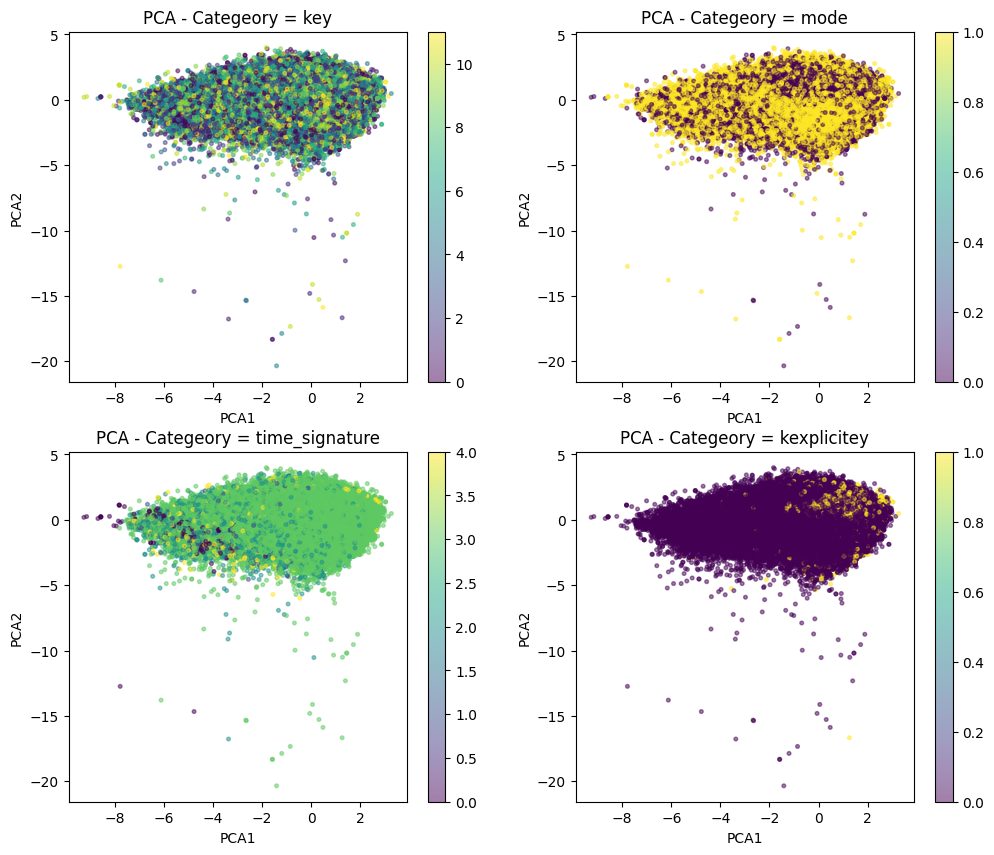

In [76]:
category = ['key', 'mode', 'time_signature', 'explicit']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sc = axes[0,0].scatter(data2D[:, 0], data2D[:, 1],c=df['key'].astype('category').cat.codes, s=7, alpha=0.5)
axes[0,0].set_title("PCA - Categeory = key")
axes[0,0].set_xlabel("PCA1")
axes[0,0].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[0,0])

sc = axes[0,1].scatter(data2D[:, 0], data2D[:, 1],c=df['mode'].astype('category').cat.codes, s=7, alpha=0.5)
axes[0,1].set_title("PCA - Categeory = mode")
axes[0,1].set_xlabel("PCA1")
axes[0,1].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[0,1])

sc = axes[1,0].scatter(data2D[:, 0], data2D[:, 1],c=df['time_signature'].astype('category').cat.codes, s=7, alpha=0.5)
axes[1,0].set_title("PCA - Categeory = time_signature")
axes[1,0].set_xlabel("PCA1")
axes[1,0].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[1,0])

sc = axes[1,1].scatter(data2D[:, 0], data2D[:, 1],c=df['explicit'].astype('category').cat.codes, s=7, alpha=0.5)
axes[1,1].set_title("PCA - Categeory = kexplicitey")
axes[1,1].set_xlabel("PCA1")
axes[1,1].set_ylabel("PCA2")

plt.colorbar(sc, ax=axes[1,1])

In [55]:
print(pca3D.explained_variance_ratio_)
print(pca2D.explained_variance_ratio_)

[0.28739016 0.15239554 0.1234026 ]
[0.28739016 0.15239554]


In [ ]:
df["hit"] = df["popularity"] >= 65
df = df.drop(columns=["popularity"])
df.describe(include='all')

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,hit
count,113999.000000,113999,113999,113999,113999,1.139990e+05,113999,113999.000000,113999.000000,113999.000000,...,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999,113999
unique,NaN,89740,31437,46589,73608,NaN,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114,2
top,NaN,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic,False
freq,NaN,9,279,195,151,NaN,104252,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000,104522
mean,56999.421925,NaN,NaN,NaN,NaN,2.280312e+05,NaN,0.566801,0.641383,5.309126,...,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,NaN,NaN
std,32909.243463,NaN,NaN,NaN,NaN,1.072961e+05,NaN,0.173543,0.251530,3.559999,...,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,8.586000e+03,NaN,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,28499.500000,NaN,NaN,NaN,NaN,1.740660e+05,NaN,0.456000,0.472000,2.000000,...,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,NaN,NaN
50%,56999.000000,NaN,NaN,NaN,NaN,2.129060e+05,NaN,0.580000,0.685000,5.000000,...,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN,NaN
75%,85499.500000,NaN,NaN,NaN,NaN,2.615060e+05,NaN,0.695000,0.854000,8.000000,...,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,NaN,NaN
